# Sales Prediction
## DSN Bootcamp Qualification Hackathon 2026 ML Track

# **By Gideon Silas**

#### GOAL: 
To build a machine learning model that predicts total sales for a given product at a given store,
based on what's known about the product and the outlet it's sold in.
#### What I cover:
- Import the libraries/packages
- Getting the data ready
- Data cleaning and validation
- Exploratory Aata Analysis
- Feature preprocessing
- Choose and fit the model
- Evaluating the model
- Feature importance
- Summary & Findings

## Import the libraries/packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split,  GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Load the Data

In [5]:
train = pd.read_csv(r"C:\Users\USER\Downloads\train.csv")
test = pd.read_csv(r"C:\Users\USER\Downloads\test.csv")
sample_submission = pd.read_csv(r"C:\Users\USER\Downloads\sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train

Train shape: (6818, 13)
Test shape: (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6813,row_08518,PRD-V56VKT,9.201,Regular,0.2851,Fruits and Vegetables,136.57,STORE-JOR,34,NaN,Tier_3,Corner Shop,276.50
6814,row_08519,PRD-S1AWP0,15.770,Low Fat,0.1193,FROZEN FOODS,74.03,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1265.63
6815,row_08520,PRD-NCP2VI,17.665,Low Fat,0.0182,Health and Hygiene,234.87,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,6254.55
6816,row_08521,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1658.06


# Data Information

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


# Check missing values

In [9]:
print("Missing values in test:")
print(test.isna().sum())

Missing values in test:
id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64


In [10]:
print("Missing values in train:")
print(train.isna().sum())

Missing values in train:
id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64


# Check for duplicates:

In [12]:
print("Duplicate rows in train:", train.duplicated().sum())

Duplicate rows in train: 0


# Confirm the category casing issues:

In [14]:
print("Unique product_category values(train):", train["product_category"].nunique())
print(sorted(train["product_category"].unique()))

Unique product_category values(train): 48
['BAKING GOODS', 'BREADS', 'BREAKFAST', 'Baking Goods', 'Breads', 'Breakfast', 'CANNED', 'Canned', 'DAIRY', 'Dairy', 'FROZEN FOODS', 'FRUITS AND VEGETABLES', 'Frozen Foods', 'Fruits and Vegetables', 'HARD DRINKS', 'HEALTH AND HYGIENE', 'HOUSEHOLD', 'Hard Drinks', 'Health and Hygiene', 'Household', 'MEAT', 'Meat', 'OTHERS', 'Others', 'SEAFOOD', 'SNACK FOODS', 'SOFT DRINKS', 'STARCHY FOODS', 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods', 'baking goods', 'breads', 'breakfast', 'canned', 'dairy', 'frozen foods', 'fruits and vegetables', 'hard drinks', 'health and hygiene', 'household', 'meat', 'others', 'seafood', 'snack foods', 'soft drinks', 'starchy foods']


## Standadize the categorical casing across both train and test:

In [16]:
for df in [train, test]:
    df["product_category"] = df["product_category"].str.lower().str.strip()

print("Unique category after fix:", train["product_category"].nunique())
print(sorted(train["product_category"].unique()))

Unique category after fix: 16
['baking goods', 'breads', 'breakfast', 'canned', 'dairy', 'frozen foods', 'fruits and vegetables', 'hard drinks', 'health and hygiene', 'household', 'meat', 'others', 'seafood', 'snack foods', 'soft drinks', 'starchy foods']


# Handle missing Values:
## Fix the missing product_weight_kg

In [18]:
# Building the lookup table

combined_weights = pd.concat([train[["product_code", "product_weight_kg"]],
                                     test[["product_code", "product_weight_kg"]]])

In [19]:
## Using the lookup to fill the gaps

weight_lookup = combined_weights.groupby("product_code")["product_weight_kg"].mean()

for df in [train, test]:
    df["product_weight_kg"] = df["product_weight_kg"].fillna(df["product_code"].map(weight_lookup))

print("Remaining missing weights - train:", train["product_weight_kg"].isna().sum())
print("Remaining missing weights - test:", test["product_weight_kg"].isna().sum())

Remaining missing weights - train: 2
Remaining missing weights - test: 2


In [20]:
# Let's clean with the overall median weight

overall_median_weight = train["product_weight_kg"].median()

for df in [train, test]:
    df["product_weight_kg"] = df["product_weight_kg"].fillna(overall_median_weight)

print("Final missing weights - train:", train["product_weight_kg"].isna().sum())
print("Final missing weights - test:", test["product_weight_kg"].isna().sum())

Final missing weights - train: 0
Final missing weights - test: 0


## Fix the missing store_size

In [22]:
# Building a lookup table: most common store_size per store_code

combined_sizes = pd.concat([train[["store_code", "store_size"]],
                                     test[["store_code", "store_size"]]])

In [23]:
# Using the lookup to fill the missing ones using mode

size_lookup = combined_sizes.groupby("store_code")["store_size"].agg(
    lambda x: x.mode()[0] if not x.mode().empty else None
)

for df in [train, test]:
    df["store_size"] = df["store_size"].fillna(df["store_code"].map(size_lookup))

print("Remaining missing store_size - train:", train["store_size"].isna().sum())
print("Remaining missing store_size - test:", test["store_size"].isna().sum())

Remaining missing store_size - train: 1919
Remaining missing store_size - test: 491


### Investigate what is different about the stores with missing size:

In [25]:
# Checking whether the missing store_size rows are concentrated in one particular store_format

missing_size_rows = train[train["store_size"].isna()]

print("store_format breakdown for rows with MISSING store_size:")
print()
missing_size_rows["store_format"].value_counts()

store_format breakdown for rows with MISSING store_size:



store_format
Standard Supermarket    1480
Corner Shop              439
Name: count, dtype: int64

In [26]:
print("store_format breakdown for ALL rows:")
print()
train["store_format"].value_counts()

store_format breakdown for ALL rows:



store_format
Standard Supermarket    4462
Corner Shop              866
Flagship Hypermarket     748
Superstore               742
Name: count, dtype: int64

### Check what size is typical within each of these two format

In [28]:
print("store_size_distribution WITHIN Standard Supermarket (kmown values only):")
print()
print(train[train["store_format"] == "Standard Supermarket"]["store_size"].value_counts())

store_size_distribution WITHIN Standard Supermarket (kmown values only):

store_size
Small     1506
Large      748
Medium     728
Name: count, dtype: int64


In [29]:
print("store_size_distribution WITHIN Corner Shop (kmown values only):")
print()
print(train[train["store_format"] == "Corner Shop"]["store_size"].value_counts())

store_size_distribution WITHIN Corner Shop (kmown values only):

store_size
Small    427
Name: count, dtype: int64


### Apply the fill using store_format as the fallback rule:

In [31]:
# Fill missing store_size base on the most common size within that store_format

format_size_lookup = {
    "Corner Shop": "Small",
    "Standard Supermarket": "Small"
}

for df in [train, test]:
    missing_mask = df["store_size"].isna()
    df.loc[missing_mask, "store_size"] = df.loc[missing_mask, "store_format"].map(format_size_lookup)

print("Remaining missing store_size - train:", train["store_size"].isna().sum())
print("Remaining missing store_size - test:", test["store_size"].isna().sum())

Remaining missing store_size - train: 0
Remaining missing store_size - test: 0


## Final full check of missing values

In [33]:
print("Train missing values:")
print(train.isna().sum())

Train missing values:
id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64


In [34]:
print("Test missing values:")
print(test.isna().sum())

Test missing values:
id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
dtype: int64


# Exploratory Data Analysis

In [36]:
# Summary statistics

train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,6818.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.867646,0.065527,140.473623,34.178205,2174.756574
std,4.643943,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.770000,0.026600,93.280000,28.000000,834.792500
50%,12.695500,0.053200,142.065000,33.000000,1790.890000
75%,16.924250,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


## Plot the Distribution of the target 

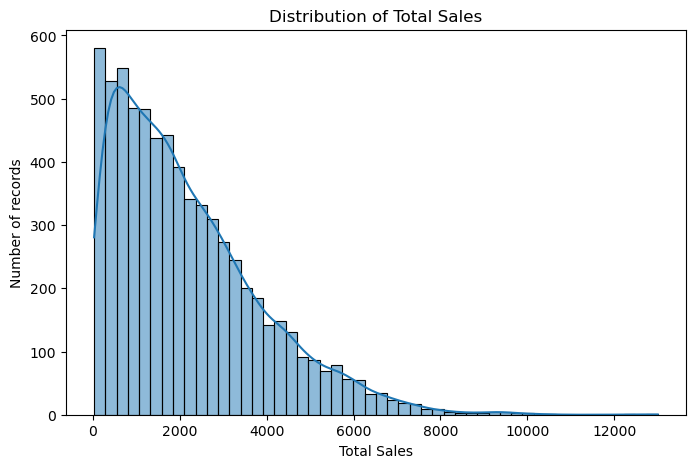

In [38]:
# Using histplot

plt.figure(figsize = (8, 5))

sns.histplot(train["total_sales"], bins = 50, kde = True)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Number of records")

plt.show()

### Insight:
This visual shows that Mean (2,174.76) is well above the median (1,790.89).
Since the competition scores on RMSE, and RMSE squares errors, that long tail of high-sales outliers will disproportionately punish MY model if it is not handled. A few badly-predicted high-sales rows can wreck my score even if most predictions are good.

## Log-transform the skewed target
To safely handles any value close to or at 0 without breaking

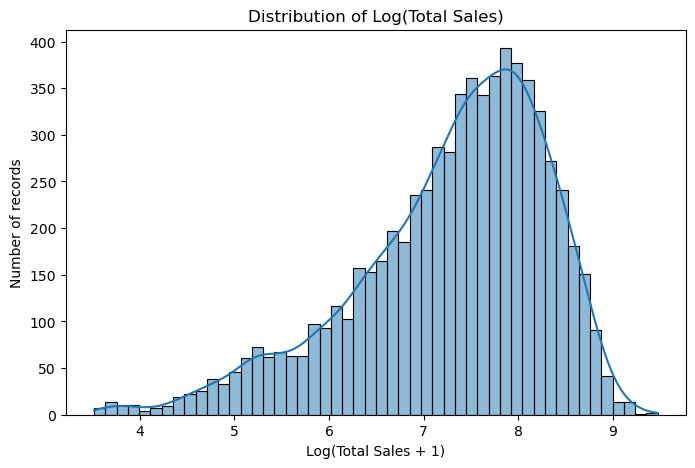

In [41]:
train["log_total_sales"] = np.log1p(train["total_sales"])

plt.figure(figsize = (8, 5))
sns.histplot(train["log_total_sales"], bins = 50, kde = True)
plt.title("Distribution of Log(Total Sales)")
plt.xlabel("Log(Total Sales + 1)")
plt.ylabel("Number of records")

plt.show()

### Insight:
The log-transformed target is now much closer to a normal, bell-shaped distribution, peaked around 8, with reasonably symmetric tails on both sides (rather than that harsh drop-off you saw before). Still slightly left-leaning (a small tail down toward 4), but this is a massive improvement, though.

## Plot Sales by categorical features
To show whether store format/size is doing meaningful work

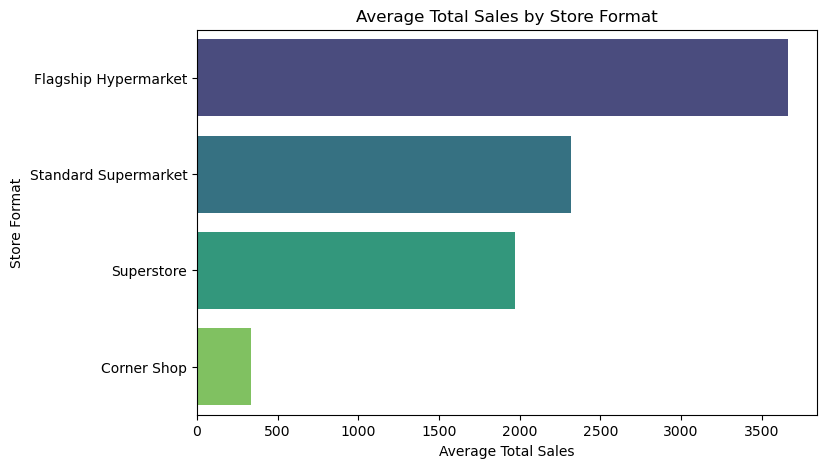

In [44]:
# Average sales by store format

plt.figure(figsize = (8, 5))

avg_sales_format = train.groupby("store_format")["total_sales"].mean().sort_values(ascending = False)

sns.barplot(x = avg_sales_format.values, y = avg_sales_format.index, palette = "viridis")
plt.title("Average Total Sales by Store Format")
plt.xlabel("Average Total Sales")
plt.ylabel("Store Format")

plt.show()

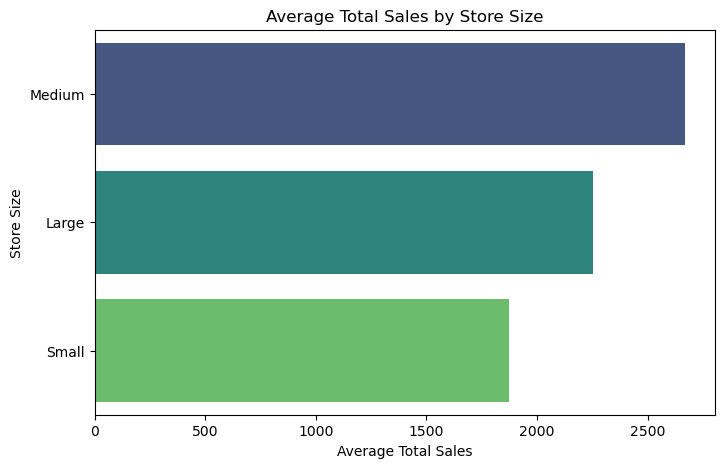

In [45]:
# Average sales by store size

plt.figure(figsize = (8, 5))

avg_sales_size = train.groupby("store_size")["total_sales"].mean().sort_values(ascending = False)

sns.barplot(x = avg_sales_size.values, y = avg_sales_size.index, palette = "viridis")
plt.title("Average Total Sales by Store Size")
plt.xlabel("Average Total Sales")
plt.ylabel("Store Size")

plt.show()

### Two very useful findings here:
1. Store Format: Clean, sensible gradient. Flagship Hypermarket (approx 3,500) > Standard Supermarket (approx 2,300) > Superstore (approx 2,000) > Corner Shop (approx 350, a huge drop). This makes intuitive business sense: bigger store formats sell more. store_format is clearly a strong, meaningful predictor.
2. Store Size: Here is the interesting part: Medium, Large, and Small are all clustered close together (roughly 1,900–2,300), with no dramatic separation the way store_format showed.

## Plot Average Sales by product category

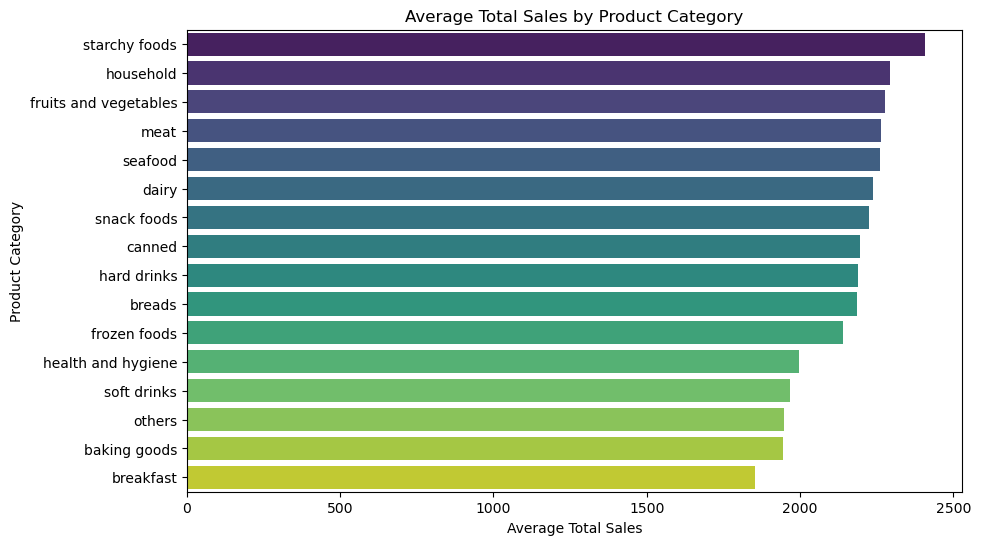

In [48]:
plt.figure(figsize = (10, 6))

avg_sales_cat = train.groupby("product_category")["total_sales"].mean().sort_values(ascending = False)

sns.barplot(x = avg_sales_cat.values, y = avg_sales_cat.index, palette = "viridis")
plt.title("Average Total Sales by Product Category")
plt.xlabel("Average Total Sales")
plt.ylabel("Product Category")

plt.show()

### Insight:
Here, all 16 product categories here sit tightly clustered between roughly 1,900 and 2,300.
To avoid assumption, so the real question becomes: if not category, what is actually driving sales? 

Now, the best candidate left to check is product_price and store_age_years, since those are numeric.

# Check numeric feature relationships with sales

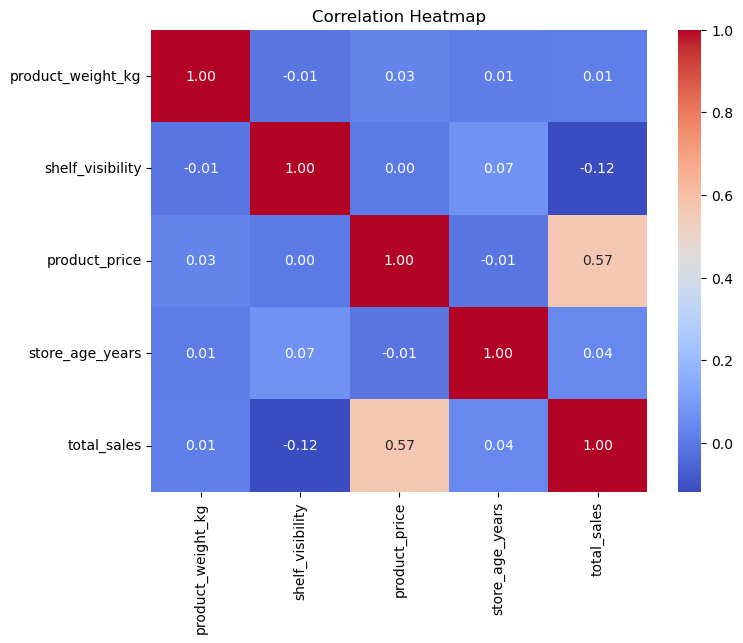

In [51]:
# Plot the correlation heatmap of numeric features

plt.figure(figsize = (8, 6))

numeric_cols = ["product_weight_kg", "shelf_visibility", "product_price", "store_age_years", "total_sales"]
corr = train[numeric_cols].corr()

sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Heatmap")

plt.show()

### Insight:
That confirms the hypothesis clearly: product_price correlates with total_sales at 0.57, by far the strongest numeric relationship in the dataset, way ahead of product_weight_kg (0.01), shelf_visibility (-0.12), and store_age_years (0.04), all of which are essentially noise.

So, here is the emerging story for this dataset, very different from your crop yield project:
- product_price is the dominant driver, not product_category like we might have assumed.
- product_category, store_size, store_age_years, shelf_visibility, product_weight_kg all look individually weak.
- store_format showed a real, meaningful spread earlier.

## Scatter plot: price vs sales

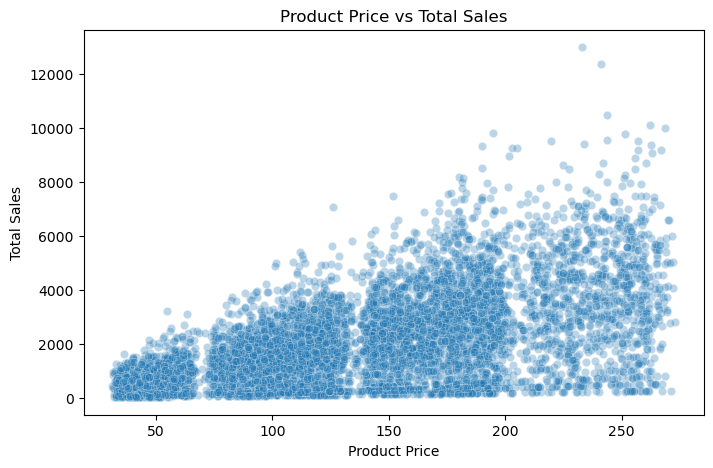

In [54]:
plt.figure(figsize = (8, 5))

sns.scatterplot(x = "product_price", y = "total_sales", data = train, alpha = 0.3)
plt.title("Product Price vs Total Sales")
plt.xlabel("Product Price")
plt.ylabel("Total Sales")

plt.show()

### Insight:
The scatter plot backs this up visually. You can see the "floor" of the point cloud rising steadily as price increases (as price goes from 50 - 250, the lower bound of sales climbs from near-0 up to around 2,000-4,000), and the handful of true outliers at 10,000-12,000+ sales cluster toward the higher-price end too.

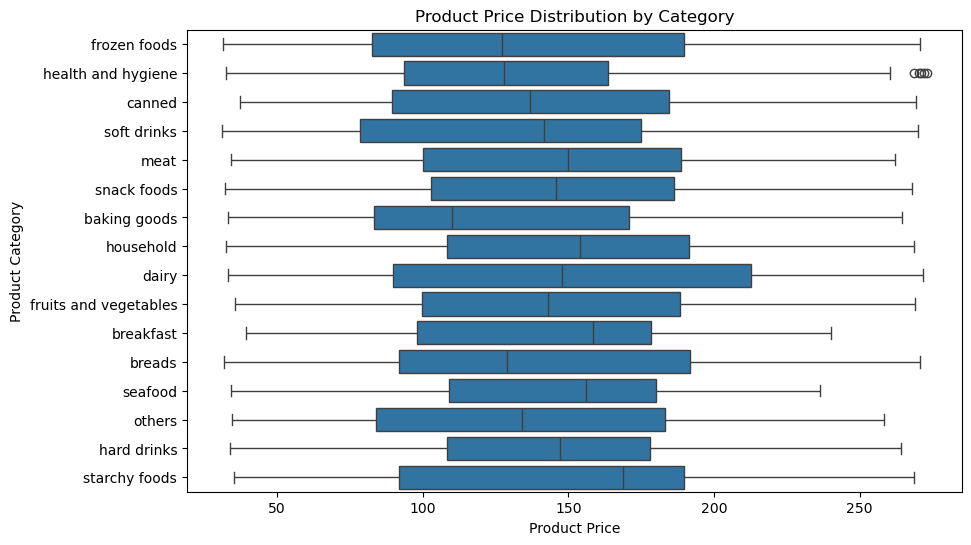

In [56]:
# Let's verify price isn't just a proxy for category

plt.figure(figsize = (10, 6))

sns.boxplot(x = "product_price", y = "product_category", data = train)
plt.title("Product Price Distribution by Category")
plt.xlabel("Product Price")
plt.ylabel("Product Category")

plt.show()

### Insight:
This confirms it clearly: the price ranges overlap heavily across every single category. Every box spans roughly 50–200+, and the whiskers stretch to similar extremes across the board (frozen foods, dairy, snack foods, starchy foods, all look nearly identical in spread). There's no category that's cleanly "cheap" or "expensive" as a whole.

At this point, the EDA story is solid:
- total_sales needed a log-transform (done)
- product_price is the strongest single driver (0.57 correlation), and it's independent of category
- store_format shows a clear, meaningful spread
- store_size, product_category, store_age_years, product_weight_kg, shelf_visibility all look individually weak on their own

# Feature Engineering and Encoding

In [59]:
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,log_total_sales
0,row_00000,PRD-PRFP9S,14.252000,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98,7.476461
1,row_00001,PRD-PXXK71,7.698000,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,5.838109
2,row_00002,PRD-V5MOIJ,14.264000,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85,5.939776
3,row_00003,PRD-UN5Z3J,12.899667,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72,8.629936
4,row_00004,PRD-6RDQYB,10.338000,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,7.773325


## Label-encode the categorical columns

In [61]:
cat_features = ["fat_content", "product_category", "store_code", "store_size", "store_location_tier", "store_format"]
encoders = {}

for col in cat_features:
    le = LabelEncoder()
    train[col + "_encoded"] = le.fit_transform(train[col])

# Use the same encoder to transform test, handling unseen categories safely

    test[col + "_encoded"] = test[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    encoders[col] = le

In [62]:
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,log_total_sales,fat_content_encoded,product_category_encoded,store_code_encoded,store_size_encoded,store_location_tier_encoded,store_format_encoded
0,row_00000,PRD-PRFP9S,14.252000,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98,7.476461,0,5,3,0,2,2
1,row_00001,PRD-PXXK71,7.698000,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,5.838109,0,8,9,2,0,2
2,row_00002,PRD-V5MOIJ,14.264000,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85,5.939776,1,3,1,1,0,2
3,row_00003,PRD-UN5Z3J,12.899667,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72,8.629936,1,14,0,1,2,1
4,row_00004,PRD-6RDQYB,10.338000,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,7.773325,1,10,2,2,1,2


In [63]:
test.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,fat_content_encoded,product_category_encoded,store_code_encoded,store_size_encoded,store_location_tier_encoded,store_format_encoded
0,row_00009,PRD-2WLNC8,8.628000,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore,0,9,5,1,2,3
1,row_00015,PRD-LV9PLM,6.993000,Low Fat,0.0579,health and hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket,0,8,2,2,1,2
2,row_00019,PRD-ET6ZI7,17.167667,Low Fat,0.1262,fruits and vegetables,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,0,6,0,1,2,1
3,row_00020,PRD-6RX35U,14.034000,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,Small,Tier_2,Standard Supermarket,1,5,4,2,1,2
4,row_00023,PRD-I4J38V,13.063000,Low Fat,0.0650,frozen foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,0,5,1,1,0,2


# Prepare features and target using the log-transformed target
Why training on log_total_sales, not raw total_sales: I established earlier that the raw target is badly right-skewed and log-transforming it made it much closer to normal.

In [65]:
# Build X and y for training, using the log-transformed target

feature_cols = [
    "product_weight_kg", "shelf_visibility", "product_price", "store_age_years",
    "fat_content_encoded", "product_category_encoded", "store_code_encoded",
    "store_size_encoded", "store_location_tier_encoded", "store_format_encoded"
]

X = train[feature_cols]
y = train["log_total_sales"]

X.head()

,product_weight_kg,shelf_visibility,product_price,store_age_years,fat_content_encoded,product_category_encoded,store_code_encoded,store_size_encoded,store_location_tier_encoded,store_format_encoded
0,14.252000,0.0271,81.37,45,0,5,3,0,2,2
1,7.698000,0.0720,42.05,35,0,8,9,2,0,2
2,14.264000,0.0421,41.35,33,1,3,1,1,0,2
3,12.899667,0.0449,174.35,47,1,14,0,1,2,1
4,10.338000,0.0120,203.06,28,1,10,2,2,1,2


In [66]:
y

0       7.476461
1       5.838109
2       5.939776
3       8.629936
4       7.773325
          ...   
6813    5.625821
6814    7.144115
6815    8.741224
6816    7.414006
6817    6.896168
Name: log_total_sales, Length: 6818, dtype: float64

## Scale the features

In [68]:
scaler = StandardScaler()
scaledX = scaler.fit_transform(X)

scaledX

array([[ 0.29812078, -0.74525085, -0.94703782, ..., -2.12857769,
         1.09230827,  0.31339118],
       [-1.11328339,  0.12554323, -1.57707581, ...,  0.79676855,
        -1.36962819,  0.31339118],
       [ 0.30070498, -0.45433969, -1.58829215, ..., -0.66590457,
        -1.36962819,  0.31339118],
       ...,
       [ 1.03311047, -0.91785814,  1.51254586, ...,  0.79676855,
        -0.13865996,  0.31339118],
       [ 1.6748536 , -0.17118616, -0.34632257, ...,  0.79676855,
        -0.13865996,  0.31339118],
       [ 0.82594373, -0.95082807, -0.68938241, ...,  0.79676855,
        -1.36962819,  0.31339118]])

# train-test split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(scaledX, y, test_size = 0.2, random_state = 42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5454, 10)
X_test shape: (1364, 10)


## Train the Model

In [72]:
#create and fit a random forest

forest_reg = RandomForestRegressor(random_state = 42)
forest_reg.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Predict on the held-out test set

In [74]:
forest_preds = forest_reg.predict(X_test)

forest_preds

array([7.11498843, 6.84029006, 7.44796996, ..., 8.01331801, 7.71294272,
       4.06290087])

## Evaluate using RMSE metric on real sales

In [76]:
# Convert both predictions and actual values back from log scale to real sales

y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(forest_preds)

rmse =np.sqrt(mean_squared_error(y_test_actual, preds_actual))
r2 = r2_score(y_test_actual, preds_actual)

print("RMSE (on actual scale):", rmse)
print("R2_score:", r2)

RMSE (on actual scale): 1174.4039615140123
R2_score: 0.531557225574468


## Feature Importance

In [78]:
importances = pd.DataFrame(forest_reg.feature_importances_, index = X.columns, columns = ["Importance"])
importances = importances.sort_values(by = "Importance", ascending =False)

importances

,Importance
store_format_encoded,0.435394
product_price,0.351500
product_weight_kg,0.068635
shelf_visibility,0.058746
product_category_encoded,0.030426
store_age_years,0.020789
store_code_encoded,0.020062
fat_content_encoded,0.006340
store_location_tier_encoded,0.004792
store_size_encoded,0.003317


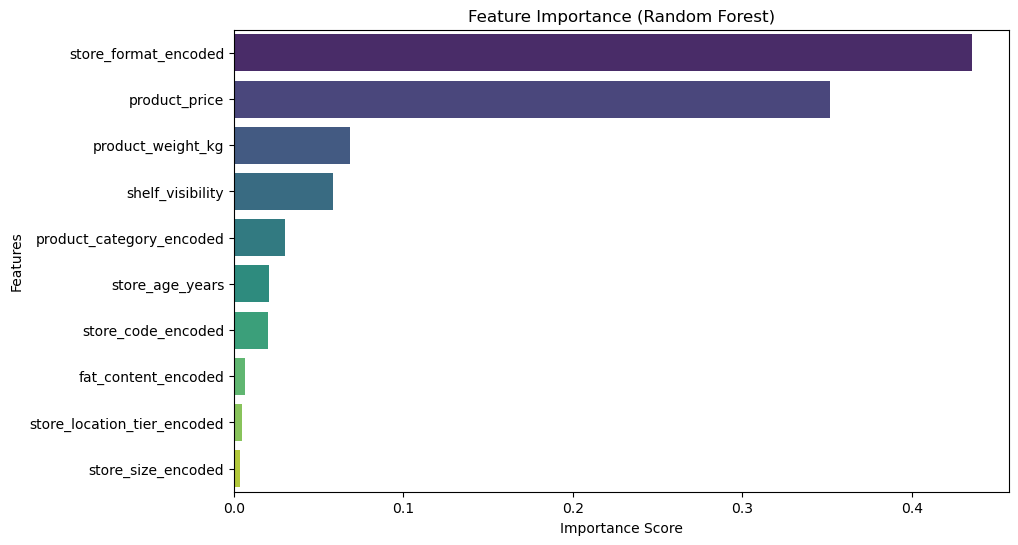

In [79]:
plt.figure(figsize=(10, 6))

sns.barplot(x = importances["Importance"], y =importances.index, palette ="viridis")

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# Try Gradient Boosting

In [81]:
# Train and fit the model

xgb_reg = GradientBoostingRegressor(random_state = 42, n_estimators = 300, learning_rate = 0.05)

xgb_reg.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

### Predict on the held-out test set

In [83]:
xgb_preds = xgb_reg.predict(X_test)

xgb_preds

array([7.14038768, 6.99536272, 7.49297789, ..., 7.83185499, 7.91670398,
       4.27731774])

### Evaluate using RMSE metric on real sales

In [85]:
xgb_preds_actual = np.expm1(xgb_preds)

rmse_xgb = np.sqrt(mean_squared_error(y_test_actual, xgb_preds_actual))
r2_xgb = r2_score(y_test_actual, xgb_preds_actual)

print("Gradient Boosting RMSE:", rmse_xgb)
print("Gradient Boosting R2:", r2_xgb)
print()
print("Random Forest RMSE was:", rmse)
print("Random Forest R2 was:", r2)

Gradient Boosting RMSE: 1127.7320221457048
Gradient Boosting R2: 0.5680501233153785

Random Forest RMSE was: 1174.4039615140123
Random Forest R2 was: 0.531557225574468


# Improve the Gradient Boosting Model

In [87]:
xgb_reg2 = GradientBoostingRegressor(random_state = 42, n_estimators = 500, learning_rate = 0.03, max_depth = 4)

xgb_reg2.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.03, max_depth=4, n_estimators=500,
                          random_state=42)

In [88]:
xgb_preds2 = xgb_reg2.predict(X_test)

xgb_preds2

array([7.15101666, 6.95688592, 7.51612233, ..., 7.85844765, 7.9443926 ,
       4.20151585])

### Evaluation

In [90]:
xgb_preds2_actual = np.expm1(xgb_preds2)

rmse_xgb2 = np.sqrt(mean_squared_error(y_test_actual, xgb_preds2_actual))
r2_xgb2 = r2_score(y_test_actual, xgb_preds2_actual)

print("Tuned Gradient Boosting RMSE:", rmse_xgb2)
print("Tuned Gradient Boosting R2:", r2_xgb2)

Tuned Gradient Boosting RMSE: 1137.4518954865719
Tuned Gradient Boosting R2: 0.5605721208386136


# Try Grid Search

In [92]:
param_grid = {"n_estimators": [200, 300], "learning_rate": [0.03, 0.05, 0.1], "max_depth": [3, 4, 5]}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state = 42),
    param_grid,
    cv = 3,
    scoring = "neg_mean_squared_error",
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200}


# Evaluation of best model

In [94]:
best_xgb = grid_search.best_estimator_
best_preds = best_xgb.predict(X_test)
best_preds_actual = np.expm1(best_preds)

rmse_best = np.sqrt(mean_squared_error(y_test_actual, best_preds_actual))
r2_best = r2_score(y_test_actual, best_preds_actual)

print("Best Grid-Searched Model RMSE:", rmse_best)
print("Best Grid-Searched Model R2:", r2_best)

Best Grid-Searched Model RMSE: 1131.3025369731076
Best Grid-Searched Model R2: 0.5653105984592034


# Final Gradient Boosting

In [96]:
final_xgb = GradientBoostingRegressor(random_state = 42, n_estimators = 300, learning_rate = 0.05, max_depth = 3)

final_xgb.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [97]:
final_preds = final_xgb.predict(X_test)

final_preds

array([7.14038768, 6.99536272, 7.49297789, ..., 7.83185499, 7.91670398,
       4.27731774])

## Evaluation

In [99]:
final_preds_actual = np.expm1(final_preds)

rmse_final = np.sqrt(mean_squared_error(y_test_actual, final_preds_actual))
r2_final = r2_score(y_test_actual, final_preds_actual)

print("Final Model RMSE:", rmse_final)
print("Final Model R2:", r2_final)

Final Model RMSE: 1127.7320221457048
Final Model R2: 0.5680501233153785


# Hyperparameter Tuned with Optuna

In [101]:
import optuna
from sklearn.model_selection import cross_val_score, KFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [102]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log = True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
    }

    model = GradientBoostingRegressor(random_state = 42, **params)

    kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
    scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = "neg_root_mean_squared_error")
    
    return -scores.mean()         #optuna minimizes, so return positive RMSE


study = optuna.create_study(direction = "minimize")
study.optimize(objective, n_trials=50)

print("Best RMSE (log scale, cross-validated):", study.best_value)
print("Best params:", study.best_params)

Best RMSE (log scale, cross-validated): 0.520594306452054
Best params: {'n_estimators': 441, 'learning_rate': 0.017498333813327525, 'max_depth': 2, 'subsample': 0.9538038110586093, 'min_samples_split': 19, 'min_samples_leaf': 4}


In [103]:
best_params = study.best_params
tuned_model =  GradientBoostingRegressor(random_state = 42, **best_params)
tuned_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.017498333813327525, max_depth=2,
                          min_samples_leaf=4, min_samples_split=19,
                          n_estimators=441, random_state=42,
                          subsample=0.9538038110586093)

### Predict on the held-out test set

In [105]:
tuned_preds = tuned_model.predict(X_test)

tuned_preds

array([7.14636352, 7.05822851, 7.49928748, ..., 7.75095045, 7.9037059 ,
       4.31065366])

### Evaluation

In [107]:
tuned_preds_actual = np.expm1(tuned_preds)

rmse_tuned = np.sqrt(mean_squared_error(y_test_actual, tuned_preds_actual))
r2_tuned = r2_score(y_test_actual, tuned_preds_actual)

print("Optuna-tuned RMSE:", rmse_tuned)
print("Optuna-tuned R2:", r2_tuned)

Optuna-tuned RMSE: 1127.6233515937922
Optuna-tuned R2: 0.5681333664421997


# Model Comparison Summary

In [109]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting (default-ish)", "Gradient Boosting (manual tune)",
              "Gradient Boosting (grid search)", "Final Model (n=300, 1r = 0.05, depth = 3", "Tuned-Optuna"],
    "RMSE": [rmse, 1127.7320221457048, rmse_xgb2, rmse_best, rmse_final, rmse_tuned],
    "R2": [r2, 0.5680501233153785, r2_xgb2, r2_best, r2_final, r2_tuned]
})

results = results.sort_values(by = "RMSE").reset_index(drop = True)
results

,Model,RMSE,R2
0,Tuned-Optuna,1127.623352,0.568133
1,Gradient Boosting (default-ish),1127.732022,0.568050
2,"Final Model (n=300, 1r = 0.05, depth = 3",1127.732022,0.568050
3,Gradient Boosting (grid search),1131.302537,0.565311
4,Gradient Boosting (manual tune),1137.451895,0.560572
5,Random Forest,1174.403962,0.531557


# Generate Submission

In [111]:
X_submission = test[feature_cols]
scaled_X_submission = scaler.transform(X_submission)

submission_preds_log = tuned_model.predict(scaled_X_submission)
submission_preds = np.expm1(submission_preds_log)

submission_preds[:10]

array([2451.28415578, 3789.69140398, 2806.98231216, 2704.21710914,
       2305.53823082,  347.54717279, 3576.80965476, 2876.09465498,
        335.22115666, 1842.83607384])

## Checking what sample_submission.csv expects

In [113]:
sample_submission.head()

,id,total_sales
0,row_00009,2174.76
1,row_00015,2174.76
2,row_00019,2174.76
3,row_00020,2174.76
4,row_00023,2174.76


# Build the final submission

In [115]:
submission = pd.DataFrame({"id": test["id"], "total_sales": submission_preds})

submission.head()

,id,total_sales
0,row_00009,2451.284156
1,row_00015,3789.691404
2,row_00019,2806.982312
3,row_00020,2704.217109
4,row_00023,2305.538231


In [116]:
# Save it to a csv file

submission.to_csv("submission.csv", index = False)
print("Saved! Shape:", submission.shape)

Saved! Shape: (1705, 2)


## Save Model Artifacts for Deployment

In [119]:
import joblib
import os

os.makedirs("models", exist_ok = True)

joblib.dump(tuned_model, "models/gb_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(encoders, "models/encoders.pkl")
joblib.dump(feature_cols, "models/feature_cols.pkl")

print("Saved: gb_model.pkl, scaler.pkl, encoders.pkl, feature_cols.pkl")
print("Model: Opyuna-tuned Gradient Boosting, RMSE ≈ 1123")

Saved: gb_model.pkl, scaler.pkl, encoders.pkl, feature_cols.pkl
Model: Opyuna-tuned Gradient Boosting, RMSE ≈ 1123


# SUMMARY:

Tuned-Optuna trained on log-transformed total_sales. Features: product price, weight, shelf visibility, store age, and label-encoded categoricals (fat content, product category, store code/size/location tier/format). Missing values imputed using product-code and store-format lookups rather than global means. Predictions converted back from log scale via expm1.